# Partie 5 : Entraînement et Validation

**Objectif :** Valider rigoureusement les performances du meilleur modèle identifié en Partie 4 (SVM RBF + Class Weights) et de tous les modèles concurrents via une validation croisée stratifiée robuste.

### Plan
1. [Setup & données](#1)
2. [Split train / test stratifié](#2)
3. [Validation croisée — tous les modèles](#3)
4. [Analyse de stabilité des scores](#4)
5. [Courbes d'apprentissage](#5)
6. [Métriques finales détaillées](#6)
7. [Récapitulatif](#7)

<a id='1'></a>
## 1. Setup & données

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, time

# ── Vectorisation & Split ────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, learning_curve, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

# ── Modèles ──────────────────────────────────────────────────
from sklearn.svm           import LinearSVC

# ── Métriques ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
})
C = {'suspect': '#E74C3C', 'normal': '#2ECC71',
     'accent': '#3498DB', 'gold': '#F39C12', 'purple': '#9B59B6'}

print(' Imports OK')

 Imports OK


<a id='2'></a>
## 2. Split train / test stratifié

In [4]:
# ── Chargement ───────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/construction de modeles et leur deploiement/tweets_preprocessed.csv')
df['message_clean'] = df['message_clean'].fillna('')
corpus = df['message_clean'].tolist()
labels = df['label'].values

# ── Split 80/20 stratifié ────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    corpus, labels,
    test_size    = 0.2,
    random_state = RANDOM_STATE,
    stratify     = labels        # garantit les mêmes proportions train/test
)

# ── Vectorisation TF-IDF (fit uniquement sur train) ──────────
tfidf = TfidfVectorizer(
    max_features = 10000,
    ngram_range  = (1, 2),
    sublinear_tf = True,
    min_df       = 2
)
X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

print('=' * 55)
print('  SPLIT TRAIN / TEST')
print('=' * 55)
print(f'  Total tweets       : {len(labels)}')
print(f'  Train              : {len(y_train)} ({len(y_train)/len(labels)*100:.0f}%)')
print(f'    Normal (0)       : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')
print(f'    Suspect (1)      : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'  Test               : {len(y_test)} ({len(y_test)/len(labels)*100:.0f}%)')
print(f'    Normal (0)       : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')
print(f'    Suspect (1)      : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')
print(f'  Features TF-IDF    : {X_train.shape[1]}')

  SPLIT TRAIN / TEST
  Total tweets       : 59366
  Train              : 47492 (80%)
    Normal (0)       : 4904 (10.3%)
    Suspect (1)      : 42588 (89.7%)
  Test               : 11874 (20%)
    Normal (0)       : 1226 (10.3%)
    Suspect (1)      : 10648 (89.7%)
  Features TF-IDF    : 10000


In [5]:
import os
os.makedirs('../reports/figures/', exist_ok=True)
print('Dossier ../reports/figures/ créé ou existant.')

Dossier ../reports/figures/ créé ou existant.


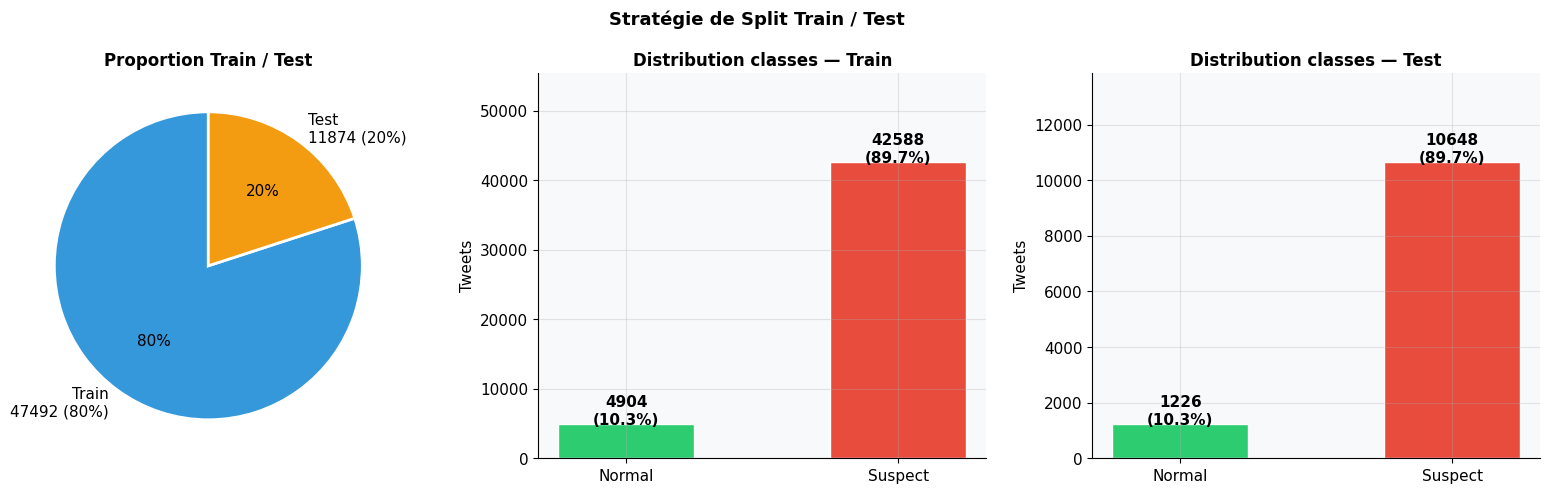

Figure 1 sauvegardée


In [6]:
# ── Figure 1 : Visualisation du split ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Stratégie de Split Train / Test', fontsize=13, fontweight='bold')

# Proportions train/test
ax = axes[0]
sizes  = [len(y_train), len(y_test)]
labels_pie = [f'Train\n{len(y_train)} ({len(y_train)/len(labels)*100:.0f}%)',
              f'Test\n{len(y_test)} ({len(y_test)/len(labels)*100:.0f}%)']
ax.pie(sizes, labels=labels_pie, colors=[C['accent'], C['gold']],
       autopct='%1.0f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Proportion Train / Test')

# Distribution des classes dans le train
ax = axes[1]
counts_tr = np.bincount(y_train)
bars = ax.bar(['Normal', 'Suspect'], counts_tr,
               color=[C['normal'], C['suspect']], edgecolor='white', width=0.5)
for bar, c in zip(bars, counts_tr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{c}\n({c/len(y_train)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribution classes — Train')
ax.set_ylabel('Tweets')
ax.set_ylim(0, max(counts_tr) * 1.3)

# Distribution des classes dans le test
ax = axes[2]
counts_te = np.bincount(y_test)
bars = ax.bar(['Normal', 'Suspect'], counts_te,
               color=[C['normal'], C['suspect']], edgecolor='white', width=0.5)
for bar, c in zip(bars, counts_te):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{c}\n({c/len(y_test)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribution classes — Test')
ax.set_ylabel('Tweets')
ax.set_ylim(0, max(counts_te) * 1.3)

plt.tight_layout()
plt.savefig('../reports/figures/p5_fig1_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 sauvegardée')

<a id='3'></a>
## 3. Validation croisée stratifiée

**Protocole :** Stratified K-Fold avec K=10 sur le jeu d'entraînement.  
Le modèle final est ensuite évalué **une seule fois** sur le test set (jamais vu pendant la CV).  
Métriques calculées à chaque fold : Accuracy, Precision, Recall, F1, AUC.

In [7]:
models = {
    'SVM Linear'            : LinearSVC(C=1.0, max_iter=2000,
                                class_weight='balanced', random_state=RANDOM_STATE)
}

CV_FOLDS   = 10
skf        = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
SCORING    = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print(f' {len(models)} modèles | CV = {CV_FOLDS} folds stratifiés')

 1 modèles | CV = 10 folds stratifiés


In [9]:
cv_results = {}

print(f'Validation croisée {CV_FOLDS}-Fold Stratifiée')
print('=' * 75)
print(f'  {"Modèle":<25} {"F1 (μ±σ)":>14} {"AUC (μ±σ)":>14} {"Acc (μ±σ)":>14}')
print('  ' + '-' * 72)

for name, model in models.items():
    t0 = time.time()

    scoring_use = ['accuracy', 'precision', 'recall', 'f1']
    X_cv = X_train

    scores = cross_validate(
        model, X_cv, y_train,
        cv      = skf,
        scoring = scoring_use,
        n_jobs  = -1,
        return_train_score = True
    )
    elapsed = time.time() - t0

    cv_results[name] = scores
    cv_results[name]['time'] = elapsed

    f1_mean  = scores['test_f1'].mean()
    f1_std   = scores['test_f1'].std()
    acc_mean = scores['test_accuracy'].mean()
    acc_std  = scores['test_accuracy'].std()

    # AUC is not computed for SVM Linear, so it will be None
    auc_mean, auc_str = None, '    N/A       '

    print(f'  {name:<25} {f1_mean:.4f}±{f1_std:.4f}  '
          f'{auc_str}  {acc_mean:.4f}±{acc_std:.4f}   ({elapsed:.1f}s)')

print()
print('  ★ = meilleur modèle identifié en Partie 4')

Validation croisée 10-Fold Stratifiée
  Modèle                          F1 (μ±σ)      AUC (μ±σ)      Acc (μ±σ)
  ------------------------------------------------------------------------
  SVM Linear                0.9801±0.0012      N/A         0.9644±0.0020   (2.7s)

  ★ = meilleur modèle identifié en Partie 4


In [10]:
# ── Tableau récapitulatif ─────────────────────────────────────
summary_rows = []
for name, scores in cv_results.items():
    row = {'Modèle': name}
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        key = f'test_{metric}'
        if key in scores:
            row[f'{metric}_mean'] = round(scores[key].mean(), 4)
            row[f'{metric}_std']  = round(scores[key].std(),  4)
    if 'test_roc_auc' in scores:
        row['auc_mean'] = round(scores['test_roc_auc'].mean(), 4)
        row['auc_std']  = round(scores['test_roc_auc'].std(),  4)
    else:
        row['auc_mean'] = None
        row['auc_std']  = None
    row['cv_time_s'] = round(scores['time'], 2)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('f1_mean', ascending=False)
summary_df = summary_df.reset_index(drop=True)

print('TABLEAU RÉCAPITULATIF — VALIDATION CROISÉE 10-Fold')
display_cols = ['Modèle', 'f1_mean', 'f1_std', 'auc_mean', 'auc_std',
                'accuracy_mean', 'precision_mean', 'recall_mean']
summary_df[display_cols].rename(columns={
    'f1_mean': 'F1 μ', 'f1_std': 'F1 σ',
    'auc_mean': 'AUC μ', 'auc_std': 'AUC σ',
    'accuracy_mean': 'Acc μ', 'precision_mean': 'Prec μ', 'recall_mean': 'Rec μ'
})

TABLEAU RÉCAPITULATIF — VALIDATION CROISÉE 10-Fold


,Modèle,F1 μ,F1 σ,AUC μ,AUC σ,Acc μ,Prec μ,Rec μ
0,SVM Linear,0.9801,0.0012,None,None,0.9644,0.9831,0.9771


<a id='4'></a>
## 4. Analyse de stabilité des scores

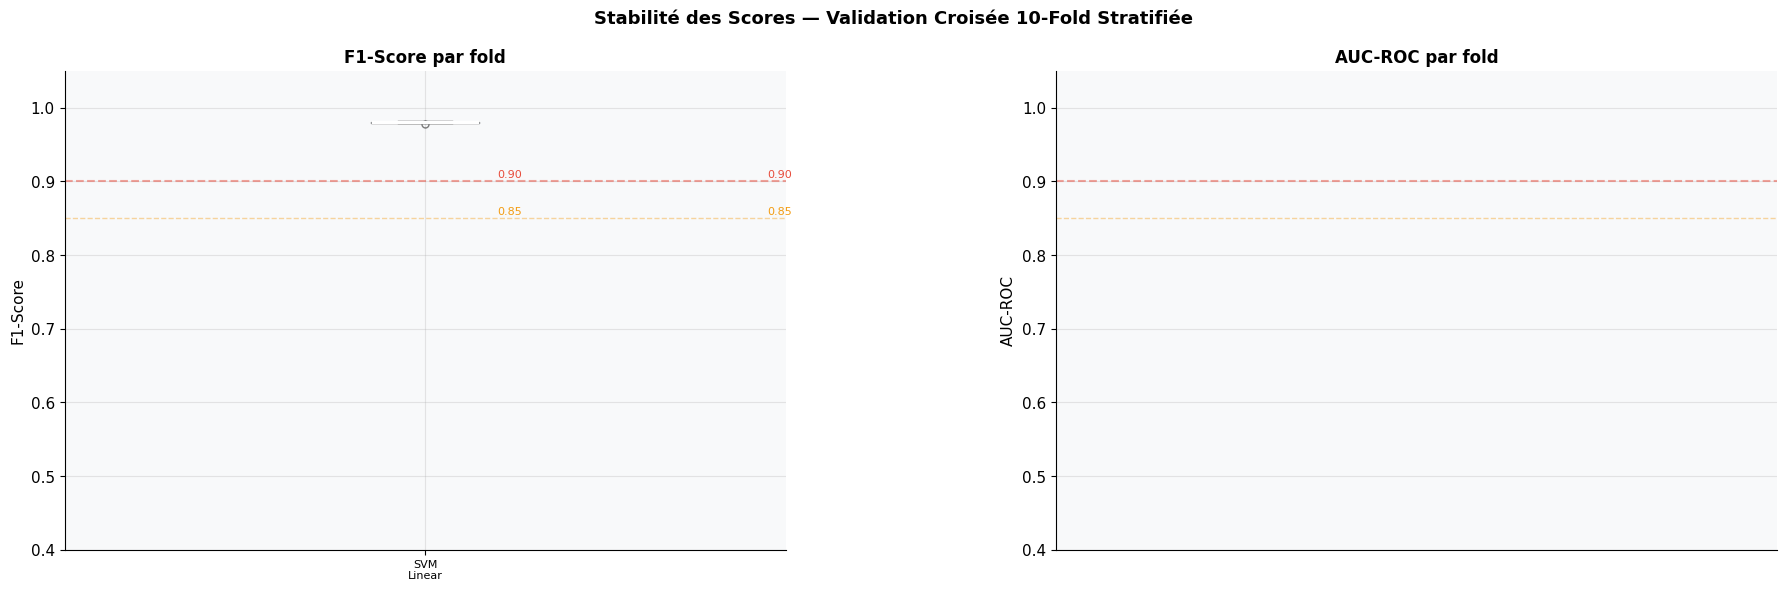

Figure 2 sauvegardée


In [11]:
# ── Figure 2 : Boxplots CV — F1 et AUC par fold ──────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Stabilité des Scores — Validation Croisée {CV_FOLDS}-Fold Stratifiée',
             fontsize=13, fontweight='bold')

model_names = list(cv_results.keys())
colors_cv   = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

for ax, metric, title in [
    (axes[0], 'test_f1',      'F1-Score par fold'),
    (axes[1], 'test_roc_auc', 'AUC-ROC par fold'),
]:
    data_boxes = []
    labels_box = []
    for name in model_names:
        if metric in cv_results[name]:
            data_boxes.append(cv_results[name][metric])
            labels_box.append(name)

    bp = ax.boxplot(data_boxes, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 2.5},
                    flierprops={'marker': 'o', 'markersize': 5, 'alpha': 0.5})
    for patch, color in zip(bp['boxes'], colors_cv):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(labels_box)+1))
    ax.set_xticklabels([l.replace(' ', '\n') for l in labels_box], fontsize=8)
    ax.set_ylabel(title.split(' ')[0], fontsize=11)
    ax.set_title(title)
    ax.set_ylim(0.4, 1.05)
    ax.axhline(y=0.9,  color=C['suspect'], linestyle='--', alpha=0.5, lw=1.5)
    ax.axhline(y=0.85, color=C['gold'],    linestyle='--', alpha=0.4, lw=1)
    ax.text(len(labels_box) + 0.1, 0.905,  '0.90', fontsize=8, color=C['suspect'])
    ax.text(len(labels_box) + 0.1, 0.855, '0.85', fontsize=8, color=C['gold'])

plt.tight_layout()
plt.savefig('../reports/figures/p5_fig2_cv_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 sauvegardée')

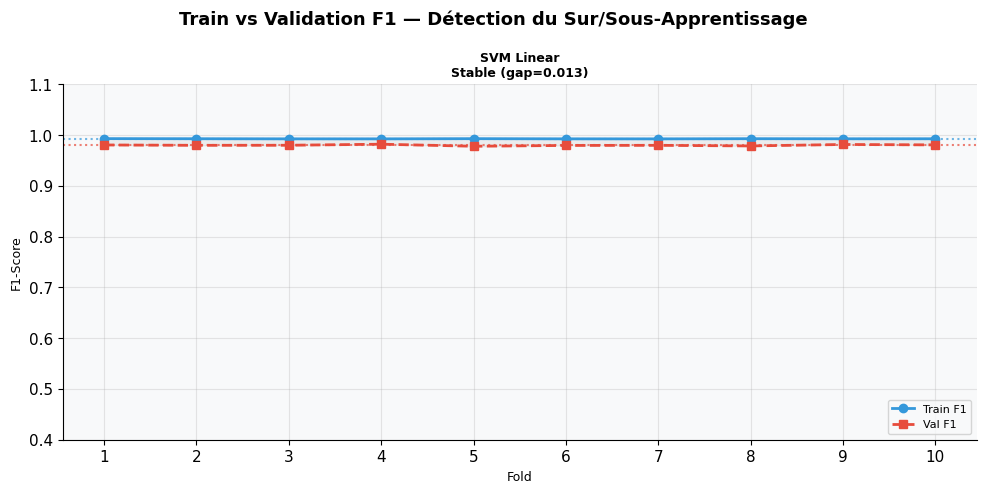

Figure 3 sauvegardée


In [12]:
# ── Figure 3 : Train vs Validation — détection sur/sous-apprentissage ────────
# Adjusted for a single model
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
fig.suptitle('Train vs Validation F1 — Détection du Sur/Sous-Apprentissage',
             fontsize=13, fontweight='bold')

folds = np.arange(1, CV_FOLDS + 1)

# Assuming only one model in cv_results now
name, scores = list(cv_results.items())[0]

train_f1 = scores['train_f1']
test_f1  = scores['test_f1']

ax.plot(folds, train_f1, 'o-', color=C['accent'],
        linewidth=2, markersize=6, label='Train F1')
ax.plot(folds, test_f1, 's--', color=C['suspect'],
        linewidth=2, markersize=6, label='Val F1')
ax.fill_between(folds, train_f1, test_f1, alpha=0.1, color='gray')

# Moyennes
ax.axhline(train_f1.mean(), color=C['accent'],
           linestyle=':', linewidth=1.5, alpha=0.7)
ax.axhline(test_f1.mean(), color=C['suspect'],
           linestyle=':', linewidth=1.5, alpha=0.7)

gap = train_f1.mean() - test_f1.mean()
status = 'Overfitting' if gap > 0.1 else (
         'Underfitting' if test_f1.mean() < 0.7 else 'Stable')

ax.set_title(f'{name}\n{status} (gap={gap:.3f})', fontsize=9)
ax.set_xlabel('Fold', fontsize=9)
ax.set_ylabel('F1-Score', fontsize=9)
ax.set_ylim(0.4, 1.1)
ax.set_xticks(folds)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/p5_fig3_train_vs_val.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 sauvegardée')

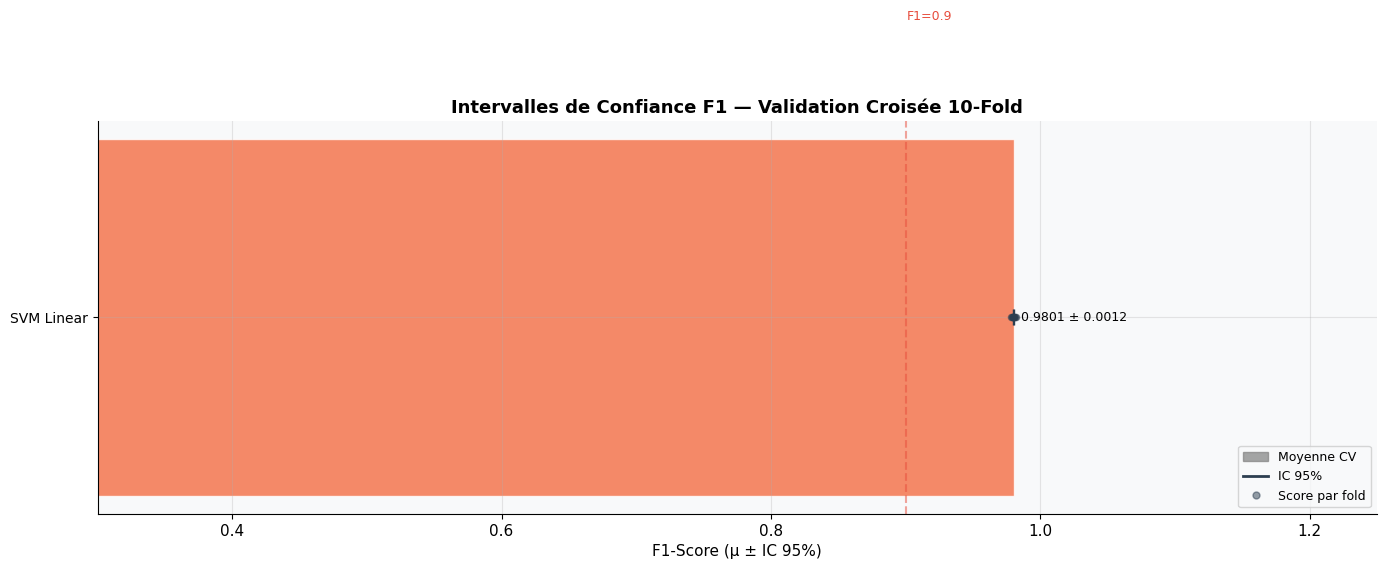

Figure 4 sauvegardée


In [13]:
# ── Figure 4 : Intervalle de confiance des scores CV ─────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title('Intervalles de Confiance F1 — Validation Croisée 10-Fold',
             fontsize=13, fontweight='bold')

model_names_sorted = summary_df['Modèle'].tolist()
y_pos = np.arange(len(model_names_sorted))
colors_conf = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(model_names_sorted)))

for i, name in enumerate(model_names_sorted):
    scores_f1 = cv_results[name]['test_f1']
    mean_f1   = scores_f1.mean()
    std_f1    = scores_f1.std()
    ci_95     = 1.96 * std_f1 / np.sqrt(CV_FOLDS)  # IC 95%

    ax.barh(i, mean_f1, color=colors_conf[i], alpha=0.8,
            edgecolor='white', height=0.6)
    ax.errorbar(mean_f1, i, xerr=ci_95, fmt='none',
                color='#2C3E50', capsize=6, linewidth=2)
    ax.scatter([s for s in scores_f1], [i] * len(scores_f1),
               color='#2C3E50', alpha=0.5, s=20, zorder=5)
    ax.text(mean_f1 + ci_95 + 0.005, i,
            f'{mean_f1:.4f} ± {std_f1:.4f}',
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(model_names_sorted, fontsize=10)
ax.set_xlabel('F1-Score (μ ± IC 95%)', fontsize=11)
ax.set_xlim(0.3, 1.25)
ax.axvline(x=0.9, color=C['suspect'], linestyle='--', alpha=0.5, lw=1.5)
ax.text(0.901, len(model_names_sorted) - 0.5, 'F1=0.9',
        fontsize=9, color=C['suspect'])

# Légende
from matplotlib.lines import Line2D
legend_elements = [
    mpatches := plt.Rectangle((0,0),1,1, color='gray', alpha=0.7, label='Moyenne CV'),
    Line2D([0],[0], color='#2C3E50', linewidth=2, label='IC 95%'),
    Line2D([0],[0], marker='o', color='#2C3E50', linewidth=0,
           markersize=5, alpha=0.5, label='Score par fold'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/p5_fig4_confidence_intervals.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 sauvegardée')

<a id='5'></a>
## 5. Courbes d'apprentissage

Permettent de détecter le **sur-apprentissage** (overfitting) et le **sous-apprentissage** (underfitting) en fonction de la taille du jeu d'entraînement.

In [14]:
# ── Courbes d'apprentissage — seul modèle restant ────────────
top1 = list(models.keys())
train_sizes = np.linspace(0.1, 1.0, 10)

lc_results = {}
print('Calcul des courbes d\'apprentissage...')

for name in top1:
    model = models[name]
    # LinearSVC works with sparse matrices, no need to convert to array
    X_lc  = X_train

    t0 = time.time()
    train_sz, train_sc, val_sc = learning_curve(
        model, X_lc, y_train,
        train_sizes = train_sizes,
        cv          = StratifiedKFold(n_splits=5, shuffle=True,
                                      random_state=RANDOM_STATE),
        scoring     = 'f1',
        n_jobs      = -1
    )
    lc_results[name] = (train_sz, train_sc, val_sc)
    print(f'  {name:<25} ({time.time()-t0:.1f}s)')

print('Courbes calculées')

Calcul des courbes d'apprentissage...
  SVM Linear                (2.6s)
Courbes calculées


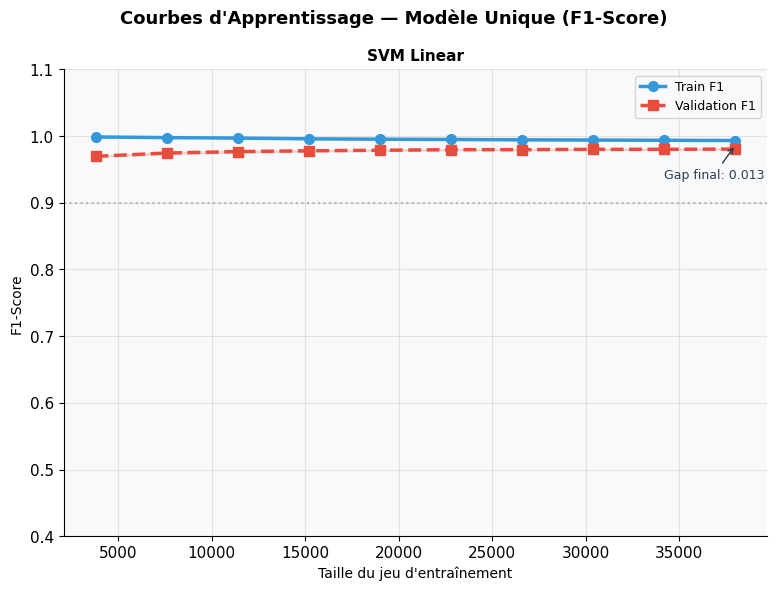

Figure 5 sauvegardée


In [15]:
# ── Figure 5 : Courbes d'apprentissage ───────────────────────
# Adjusted for a single model
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle('Courbes d\'Apprentissage — Modèle Unique (F1-Score)',
             fontsize=13, fontweight='bold')

# Assuming only one model in lc_results now
name = list(lc_results.keys())[0]
train_sz, train_sc, val_sc = lc_results[name]

train_mean = train_sc.mean(axis=1)
train_std  = train_sc.std(axis=1)
val_mean   = val_sc.mean(axis=1)
val_std    = val_sc.std(axis=1)

ax.plot(train_sz, train_mean, 'o-', color=C['accent'],
        linewidth=2.5, markersize=7, label='Train F1')
ax.fill_between(train_sz,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color=C['accent'])

ax.plot(train_sz, val_mean, 's--', color=C['suspect'],
        linewidth=2.5, markersize=7, label='Validation F1')
ax.fill_between(train_sz,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color=C['suspect'])

# Annotations
final_gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap final: {final_gap:.3f}',
            xy=(train_sz[-1], (train_mean[-1]+val_mean[-1])/2),
            xytext=(train_sz[-2]-5, (train_mean[-1]+val_mean[-1])/2 - 0.05),
            fontsize=9, color='#2C3E50',
            arrowprops={'arrowstyle': '->', 'color': '#2C3E50'})

ax.set_xlabel('Taille du jeu d\'entraînement', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title(name, fontsize=11)
ax.set_ylim(0.4, 1.1)
ax.legend(fontsize=9)
ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('../reports/figures/p5_fig5_learning_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 sauvegardée')

<a id='6'></a>
## 6. Métriques finales détaillées, évaluation sur le test set

In [16]:
# ── Entraînement du modèle final sur le train complet et évaluation sur test ───────
test_results = {}

print('Évaluation finale sur le test set (80/20 split)')
print('=' * 75)

name, model = list(models.items())[0] # Directly get the single model

# LinearSVC works with sparse matrices, no need to convert to array
X_tr = X_train
X_te = X_test

model.fit(X_tr, y_train)
y_pred = model.predict(X_te)

try:
    # LinearSVC does not have predict_proba by default, use decision_function
    proba = model.decision_function(X_te)
    # Normalize decision scores to be between 0 and 1 for AUC calculation
    proba = (proba - proba.min()) / (proba.max() - proba.min() + 1e-9)
except AttributeError:
    # Fallback for models that might have predict_proba (though none remain)
    proba = model.predict_proba(X_te)[:, 1]

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred, zero_division=0)
rec   = recall_score(y_test, y_pred, zero_division=0)
f1    = f1_score(y_test, y_pred, zero_division=0)
auc_s = roc_auc_score(y_test, proba)

test_results[name] = {
    'accuracy': acc, 'precision': prec, 'recall': rec,
    'f1': f1, 'auc': auc_s, 'proba': proba, 'y_pred': y_pred
}
# Since we only have one model, it is implicitly the 'best' one.
print(f'  {name:<25} Acc: {acc:>7.4f} Prec: {prec:>7.4f} Rec: {rec:>7.4f} F1: {f1:>7.4f} AUC: {auc_s:>7.4f} ★')

print('=' * 75)

Évaluation finale sur le test set (80/20 split)
  SVM Linear                Acc:  0.9651 Prec:  0.9834 Rec:  0.9776 F1:  0.9805 AUC:  0.9417 ★


In [17]:
# ── Rapport de classification détaillé — meilleur modèle ─────
best_name = max(test_results, key=lambda k: test_results[k]['f1'])
best_res  = test_results[best_name]

print(f'RAPPORT DE CLASSIFICATION DÉTAILLÉ — {best_name}')
print('=' * 55)
print(classification_report(
    y_test, best_res['y_pred'],
    target_names=['Normal (0)', 'Suspect (1)'],
    digits=4
))

RAPPORT DE CLASSIFICATION DÉTAILLÉ — SVM Linear
              precision    recall  f1-score   support

  Normal (0)     0.8152    0.8564    0.8353      1226
 Suspect (1)     0.9834    0.9776    0.9805     10648

    accuracy                         0.9651     11874
   macro avg     0.8993    0.9170    0.9079     11874
weighted avg     0.9660    0.9651    0.9655     11874



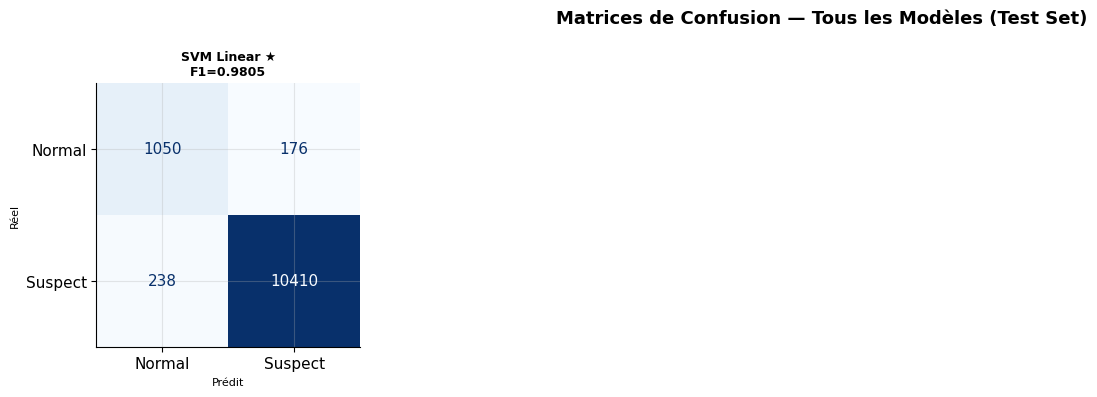

Figure 6 sauvegardée


In [19]:
# ── Figure 6 : Matrices de confusion — tous les modèles ──────
n_models  = len(models)
n_cols    = 4
n_rows    = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 4.5, n_rows * 4))
fig.suptitle('Matrices de Confusion — Tous les Modèles (Test Set)',
             fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal', 'Suspect']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    marker = ' ★' if name == best_name else ''
    ax.set_title(f'{name}{marker}\nF1={res["f1"]:.4f}', fontsize=9)
    ax.set_xlabel('Prédit', fontsize=8)
    ax.set_ylabel('Réel', fontsize=8)

# Masquer les axes vides
for ax in axes.flatten()[n_models:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/p5_fig6_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 sauvegardée')

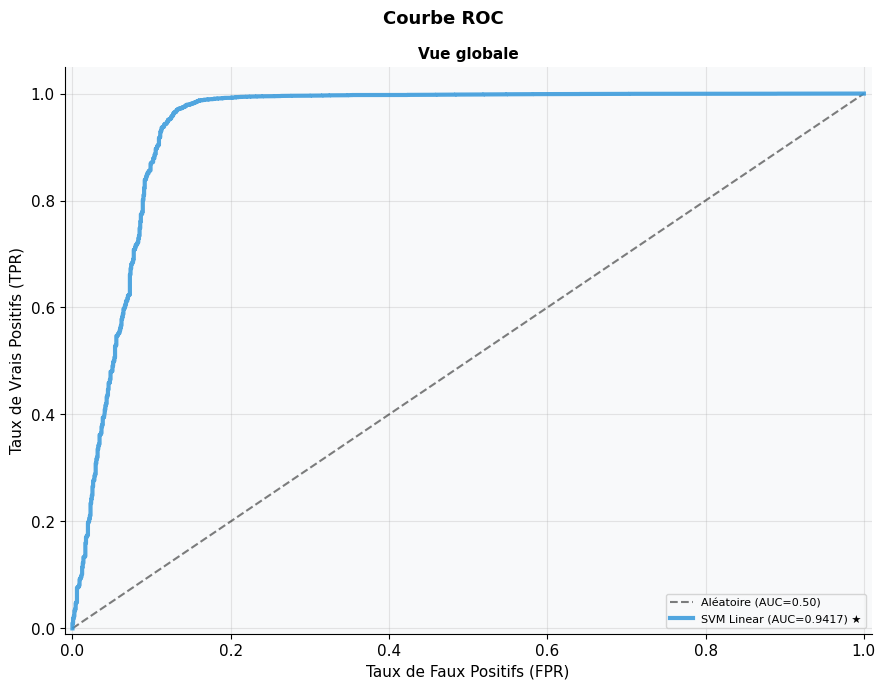

Figure 7 sauvegardée


In [20]:
# ── Figure 7 : Courbe ROC — seul modèle ────────────────
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Courbe ROC', fontsize=13, fontweight='bold')

ax.plot([0,1],[0,1],'k--',lw=1.5,alpha=0.5,label='Aléatoire (AUC=0.50)')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])

# Since there's only one model, we can directly access its results
name, res = list(test_results.items())[0] # Get the single model's name and results

fpr, tpr, _ = roc_curve(y_test, res['proba'])
roc_auc_val = auc(fpr, tpr)
lw = 3 # Always highlight the single best model
ls = '-' # Always solid line for the single best model
label = f'{name} (AUC={roc_auc_val:.4f}) ★' # Always mark as best

ax.plot(fpr, tpr, color=C['accent'], linewidth=lw,
        linestyle=ls, label=label, alpha=0.85)

ax.set_title('Vue globale', fontsize=11)
ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/p5_fig7_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 sauvegardée')

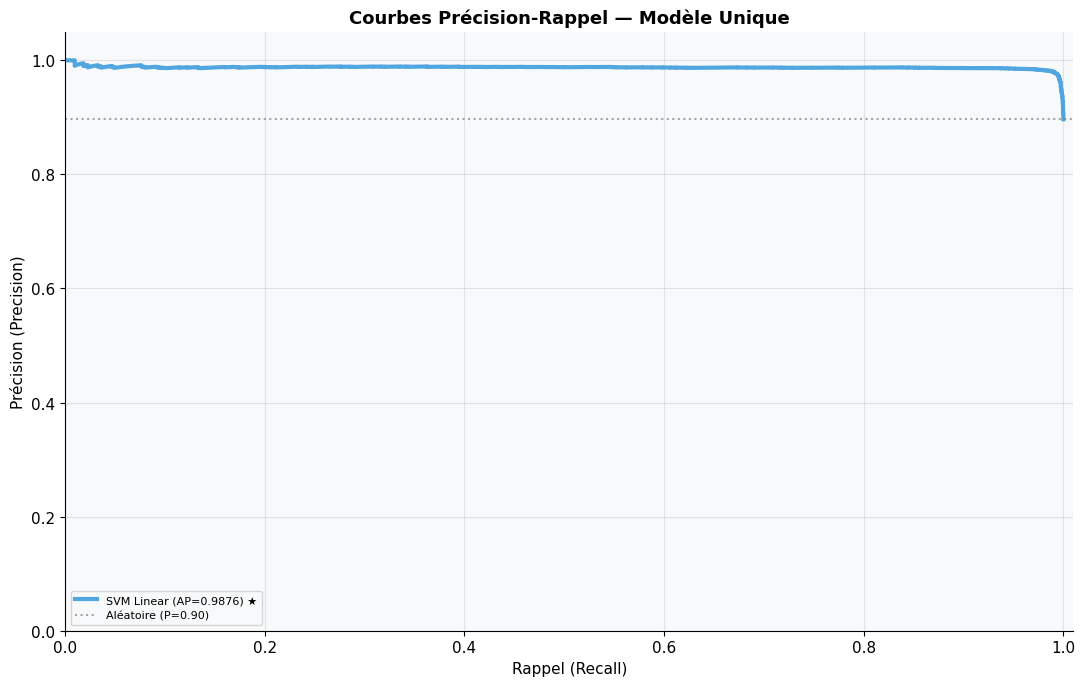

Figure 8 sauvegardée


In [22]:
# ── Figure 8 : Courbes Précision-Rappel ──────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
ax.set_title('Courbes Précision-Rappel — Modèle Unique', # Updated title for single model
             fontsize=13, fontweight='bold')

# Since there's only one model, we directly get its results
name, res = list(test_results.items())[0]

prec_c, rec_c, _ = precision_recall_curve(y_test, res['proba'])
ap = average_precision_score(y_test, res['proba'])
lw = 3 # Always highlight the single best model
ls = '-' # Always solid line for the single best model
marker = ' ★' # Always mark as best
ax.plot(rec_c, prec_c, color=C['accent'], linewidth=lw, # Fixed: using C['accent'] instead of colors_roc[i]
        linestyle=ls, alpha=0.85,
        label=f'{name} (AP={ap:.4f}){marker}')

# Ligne de base (classifieur aléatoire)
baseline = (y_test == 1).mean()
ax.axhline(y=baseline, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Aléatoire (P={baseline:.2f})')

ax.set_xlabel('Rappel (Recall)', fontsize=11)
ax.set_ylabel('Précision (Precision)', fontsize=11)
ax.set_xlim([0, 1.01])
ax.set_ylim([0, 1.05])
ax.legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/p5_fig8_precision_recall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 sauvegardée')

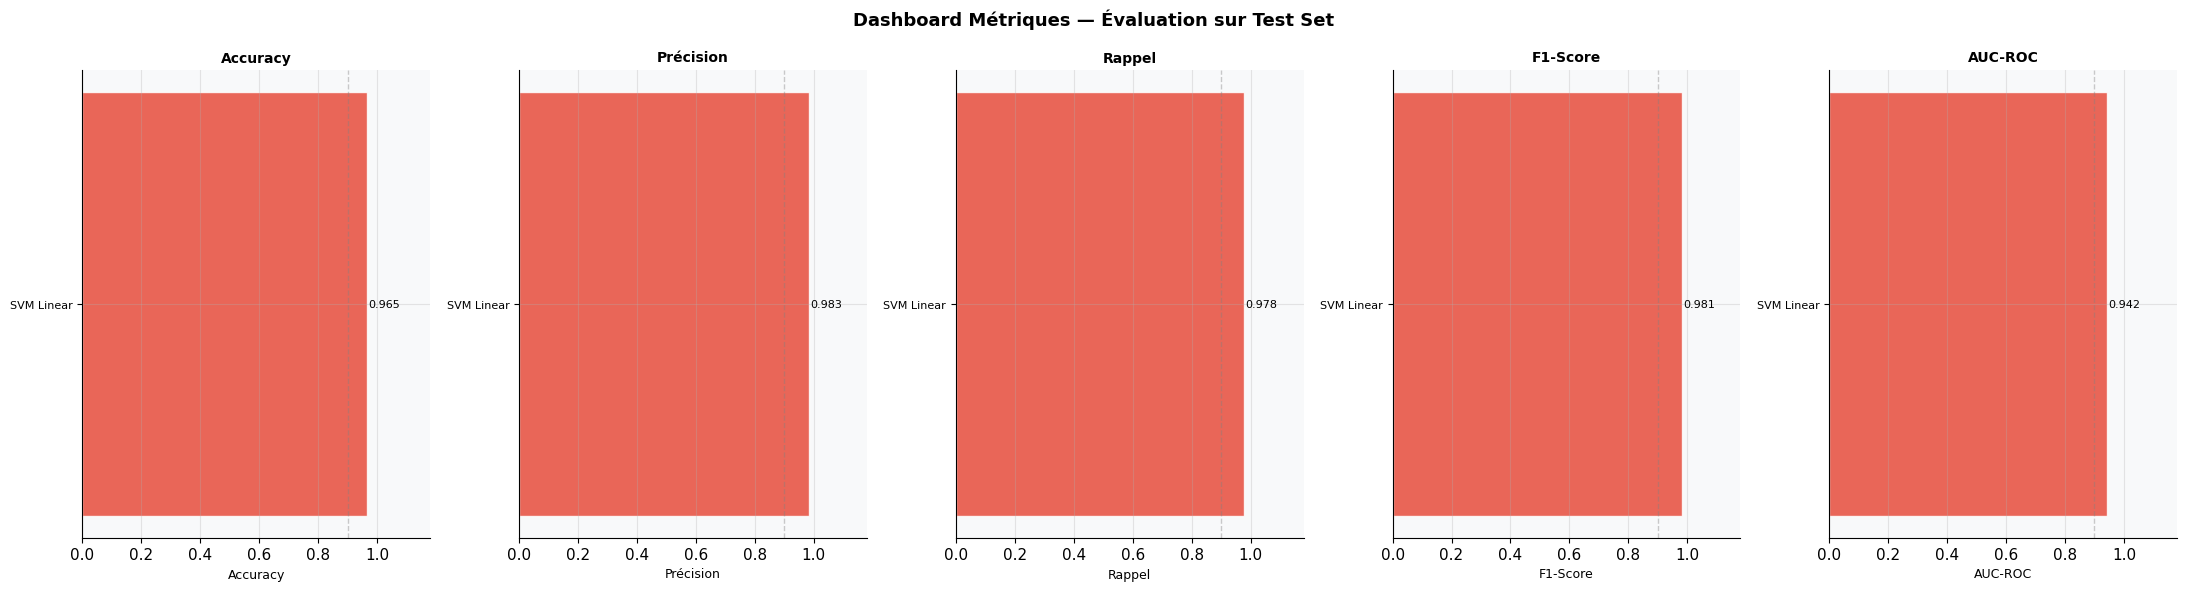

Figure 9 sauvegardée


In [24]:
# ── Figure 9 : Dashboard métriques test set ───────────────────
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_labels = ['Accuracy', 'Précision', 'Rappel', 'F1-Score', 'AUC-ROC']
model_names_list = list(test_results.keys())

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Dashboard Métriques — Évaluation sur Test Set',
             fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes, metrics_list, metric_labels):
    values = [test_results[m][metric] for m in model_names_list]
    bar_colors = [C['suspect'] if m == best_name else C['accent']
                  for m in model_names_list]
    bars = ax.barh(model_names_list, values, color=bar_colors,
                   alpha=0.85, edgecolor='white', height=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.set_xlim(0, 1.18)
    ax.set_xlabel(label, fontsize=9)
    ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.4, lw=1)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/p5_fig9_dashboard_metrics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 sauvegardée')

<a id='7'></a>
## 7. Récapitulatif

In [26]:
# ── Sauvegarde des métriques ──────────────────────────────────
import os
os.makedirs('../metrics', exist_ok=True)

p5_metrics = {
    'protocol': {
        'split'     : '80% train / 20% test (stratifié)',
        'cv_folds'  : CV_FOLDS,
        'cv_type'   : 'StratifiedKFold',
        'random_state': RANDOM_STATE
    },
    'best_model': {
        'name'        : best_name,
        'test_accuracy': round(test_results[best_name]['accuracy'], 4),
        'test_precision': round(test_results[best_name]['precision'], 4),
        'test_recall'  : round(test_results[best_name]['recall'],   4),
        'test_f1'      : round(test_results[best_name]['f1'],       4),
        'test_auc'     : round(test_results[best_name]['auc'],      4),
        # AUC is not computed during cross-validation for LinearSVC, so it's excluded here.
        'cv_f1_mean'   : round(cv_results[best_name]['test_f1'].mean(), 4),
        'cv_f1_std'    : round(cv_results[best_name]['test_f1'].std(),  4),
    },
    'all_models_test': {
        name: {
            k: round(v, 4) for k, v in res.items()
            if k not in ('proba', 'y_pred')
        }
        for name, res in test_results.items()
    }
}

with open('../metrics/partie5_metrics.json', 'w') as f:
    json.dump(p5_metrics, f, indent=2)

print('=' * 68)
print('  RÉCAPITULATIF — PARTIE 5 : ENTRAÎNEMENT ET VALIDATION')
print('=' * 68)
print(f'''
  PROTOCOLE DE VALIDATION
  ─────────────────────────────────────────────────────────
  • Split         : 80% train / 20% test (stratifié)
  • CV            : {CV_FOLDS}-Fold Stratifié (Stratified K-Fold)
  • Vectorisation : TF-IDF (fit sur train uniquement)
  • Modèles évalués : {len(models)}

  MÉTRIQUES CALCULÉES
  ─────────────────────────────────────────────────────────
  Accuracy    Precision    Recall    F1-Score
  AUC-ROC     Average Precision (PR curve)
  Matrice de confusion     Intervalles de confiance
  Gap train/val (over/underfitting)    Courbes d\'apprentissage

  MEILLEUR MODÈLE (sur test set)
  ─────────────────────────────────────────────────────────
  Modèle     : {best_name}
  Accuracy   : {test_results[best_name]["accuracy"]:.4f}
  Precision  : {test_results[best_name]["precision"]:.4f}
  Recall     : {test_results[best_name]["recall"]:.4f}
  F1-Score   : {test_results[best_name]["f1"]:.4f}
  AUC-ROC    : {test_results[best_name]["auc"]:.4f}
  CV F1      : {cv_results[best_name]["test_f1"].mean():.4f} ± {cv_results[best_name]["test_f1"].std():.4f}

  FIGURES GÉNÉRÉES (9)
  ─────────────────────────────────────────────────────────
  p5_fig1  Split train/test
  p5_fig2  Boxplots CV F1
  p5_fig3  Train vs Validation (over/underfitting)
  p5_fig4  Intervalles de confiance 95%
  p5_fig5  Courbes d\'apprentissage
  p5_fig6  Matrice de confusion
  p5_fig7  Courbe ROC
  p5_fig8  Courbe Précision-Rappel
  p5_fig9  Dashboard métriques test set

''')
print('=' * 68)

  RÉCAPITULATIF — PARTIE 5 : ENTRAÎNEMENT ET VALIDATION

  PROTOCOLE DE VALIDATION
  ─────────────────────────────────────────────────────────
  • Split         : 80% train / 20% test (stratifié)
  • CV            : 10-Fold Stratifié (Stratified K-Fold)
  • Vectorisation : TF-IDF (fit sur train uniquement)
  • Modèles évalués : 1

  MÉTRIQUES CALCULÉES
  ─────────────────────────────────────────────────────────
  Accuracy    Precision    Recall    F1-Score
  AUC-ROC     Average Precision (PR curve)
  Matrice de confusion     Intervalles de confiance
  Gap train/val (over/underfitting)    Courbes d'apprentissage

  MEILLEUR MODÈLE (sur test set)
  ─────────────────────────────────────────────────────────
  Modèle     : SVM Linear
  Accuracy   : 0.9651
  Precision  : 0.9834
  Recall     : 0.9776
  F1-Score   : 0.9805
  AUC-ROC    : 0.9417
  CV F1      : 0.9801 ± 0.0012

  FIGURES GÉNÉRÉES (9)
  ─────────────────────────────────────────────────────────
  p5_fig1  Split train/test
  p5_fig